# Self Project - Analyzing Wisconsin Fishing Data

Christian Schumacher and Gavin Hartwig  
Professor MacIsaac  
Data Science  
Spring 2026

## Introduction

For our self project, we analyzed fishing data from the last year. We took data from three lakes: Lake Mendota and Spring Lake, located in Wisconsin. We wanted to determine the distribution of fish species in the lakes, and also understand if there was any correlation between certain factors and the species of fish that was caught. 

Some of the factors we considered include:
- Which lake a fish was caught at
- Length and weight of the fish
- Bait type
Data Sets
- fish_data.csv
- ice_data.csv

We are using classification to try and predict the species type of a fish given 
certain metrics. 

Main Hypotheses:
- Temperature affects the amount of fish caught
- Rain effects amount of fish caught
- Top water is better than spinning lures
- Summer fishing catches bigger fish than Ice fishing

In [389]:
import importlib
import pandas as pd
import utils
import matplotlib.pyplot as plt
importlib.reload(utils)
from scipy.stats import ttest_ind
import seaborn as sns
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

## Data Preperation

In this section we load both data sets and clean them for future use. We begin by standardizing winter since winter does not include "Topwater", "Spinning" or "Bait". Then we clean summer by removing instances of fish that were foul hooked. After this we concatenate the winter set onto the summer set. 

In [390]:
summer = utils.load_data1("fish_data.csv")
winter = utils.load_data2("ice_data.csv")

In [391]:
winter = utils.standardize_winter(winter)
summer_clean = utils.clean_summer(summer)

fish_df = utils.merge_datasets(summer_clean, winter)
fish_df.head()

,Date,Lake,Fish_Species,Length_in,Weight_lb,Bait,Topwater,Spinning
0,2025-05-15,Lake Mendota,Northern Pike,28.4,8.9,Whopper Plopper,Yes,No
1,2025-05-15,Spring Lake,Largemouth Bass,19.2,4.1,Mepps,No,Yes
2,2025-05-16,Spring Lake,Smallmouth Bass,17.5,3.2,Mepps,No,Yes
3,2025-05-17,Lake Mendota,Northern Pike,31.1,10.5,Whopper Plopper,Yes,No
4,2025-05-17,Spring Lake,Largemouth Bass,22.3,4.7,Whopper Plopper,Yes,No


After this we retrieve the Temperature, Precipitation and Wind of the lake on these dates. After this we merge this with the data using the 'Date' index.

In [392]:
weather_df = utils.fetch_wisconsin_weather("2025-05-15", "2026-01-03")
weather_df.head()

,Date,Temp_Max,Precip,Wind_Max
0,2025-05-15,32.4,1.7,29.8
1,2025-05-16,25.9,0.7,32.0
2,2025-05-17,15.8,0.0,27.6
3,2025-05-18,19.9,0.0,18.3
4,2025-05-19,13.4,0.4,24.8


In [393]:
final_df = utils.merge_weather(fish_df, weather_df)
final_df.head()

,Date,Lake,Fish_Species,Length_in,Weight_lb,Bait,Topwater,Spinning,Temp_Max,Precip,Wind_Max
0,2025-05-15,Lake Mendota,Northern Pike,28.4,8.9,Whopper Plopper,Yes,No,32.4,1.7,29.8
1,2025-05-15,Spring Lake,Largemouth Bass,19.2,4.1,Mepps,No,Yes,32.4,1.7,29.8
2,2025-05-16,Spring Lake,Smallmouth Bass,17.5,3.2,Mepps,No,Yes,25.9,0.7,32.0
3,2025-05-17,Lake Mendota,Northern Pike,31.1,10.5,Whopper Plopper,Yes,No,15.8,0.0,27.6
4,2025-05-17,Spring Lake,Largemouth Bass,22.3,4.7,Whopper Plopper,Yes,No,15.8,0.0,27.6


Once these are merged we have finally cleaned our data. We are now ready to use it for our Data analysis. 

## Exploratory Data Analysis

In this section we use our cleaned data and analyze it. The Goal is to understand if there are correlations that would 
tell us what catches more fish. We tested Topwater vs. Spinning, Temperature vs Fish Length, Percipitation vs Fish Weight and Winter vs. Summer fishing. 

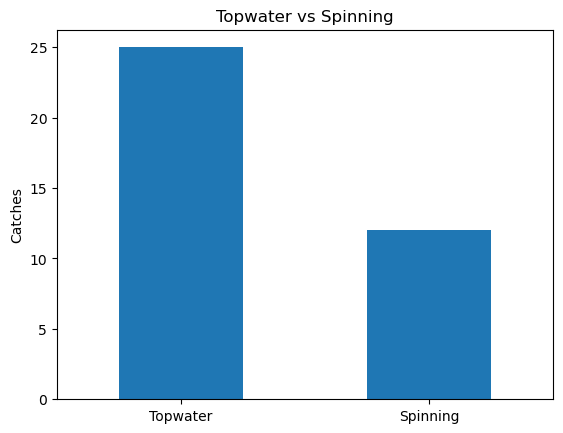

In [394]:
catches_df = final_df[(final_df["Topwater"] == "Yes") |(final_df["Spinning"] == "Yes")]

bait_types = pd.DataFrame({"Topwater": (catches_df["Topwater"] == "Yes").sum(),"Spinning": (catches_df["Spinning"] == "Yes").sum()}, index=["Count"])

bait_types.T.plot(kind="bar", legend=False)
plt.title("Topwater vs Spinning")
plt.ylabel("Catches")
plt.xticks(rotation=0)
plt.show()

Clearly Topwater bait was more effective at catching fish than spinning bait.

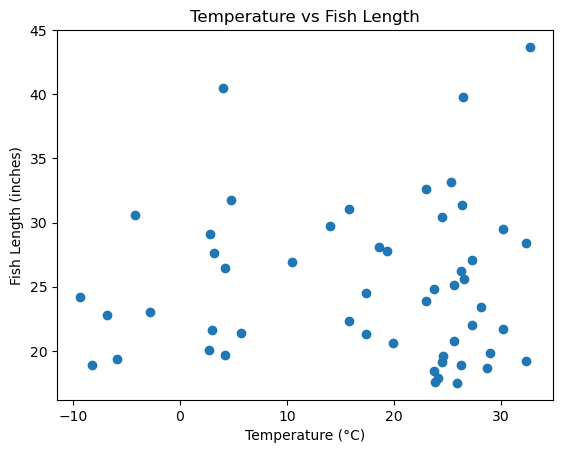

In [ ]:
plt.scatter(final_df["Temp_Max"], final_df["Length_in"])
plt.title("Fish Length vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Fish Length (inches)")
plt.show()

In [ ]:
t_stat, p_val = ttest_ind(final_df["Length_in"], final_df["Temp_Max"], equal_var=False)

print("t-stat:", t_stat)
print("p-value:", p_val)

t-stat: 4.151188835464329
p-value: 8.729396110046377e-05


p < 0.05 -> There is a statistical significance between temperature and length of fish caught.

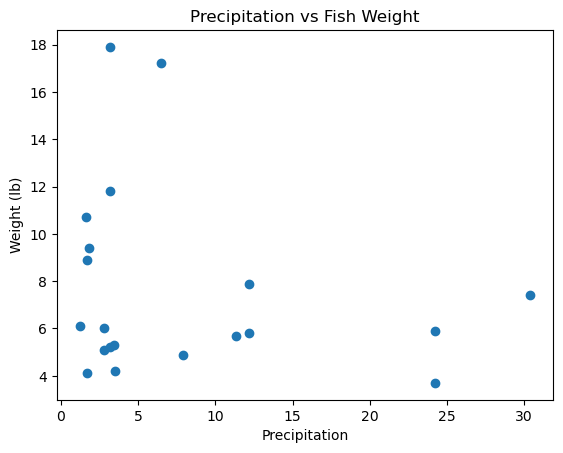

In [ ]:
rain_df = final_df[final_df["Precip"] > 1]
plt.scatter(rain_df["Precip"], rain_df["Weight_lb"])
plt.title("Precipitation vs Fish Weight")
plt.xlabel("Precipitation")
plt.ylabel("Weight (lb)")
plt.show()

In [ ]:
t_stat, p_val = ttest_ind(rain_df["Precip"], rain_df["Weight_lb"], equal_var=False)

print("t-stat:", t_stat)
print("p-value:", p_val)

t-stat: 0.13500875348365918
p-value: 0.8936151872706886


p >> 0.05 -> precipitation has no correlation to fish weight

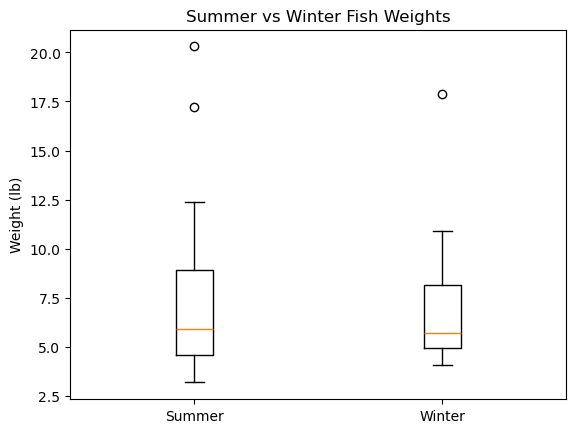

In [ ]:
data = [summer_clean["Weight_lb"].dropna(),
        winter["Weight_lb"].dropna()]

plt.boxplot(data, tick_labels=["Summer", "Winter"])
plt.title("Summer vs Winter Fish Weights")
plt.ylabel("Weight (lb)")
plt.show()

In [ ]:
summer_weights = summer["Weight_lb"].dropna()
winter_weights = winter["Weight_lb"].dropna()

t_stat, p_val = ttest_ind(summer_weights, winter_weights, equal_var=False)

print("t-stat:", t_stat)
print("p-value:", p_val)

t-stat: 0.46382881083017474
p-value: 0.6458590347090793


p >> 0.05 -> There is no significant difference between fish weights in summer and winter.

## Classification

For our classification, we predicted the Fish_Species attribute. 
We decided to only keep the following attributes in our prediction model, because the others showed no statistical significance:
- Weight
- Length
- Temperature
- Bait type

In [ ]:
df = final_df.drop(columns=["Date", "Topwater", "Spinning", "Wind_Max", "Precip"])

num_cols = df.select_dtypes(include=["number"]).columns
df[num_cols] = df[num_cols].fillna(0)

In [ ]:
df_encoded, encoders = utils.encode_data(df)
X_train, X_test, y_train, y_test = utils.split_data(df_encoded)

In [ ]:
knn = utils.run_knn(X_train, X_test, y_train, y_test, k=3)
print("kNN Accuracy:", knn)

kNN Accuracy: 0.8181818181818182


In [ ]:
decision_tree = utils.run_decision_tree(X_train, X_test, y_train, y_test)
print("Decision Tree Accuracy:", decision_tree)

Decision Tree Accuracy: 0.7272727272727273


In [ ]:
class_percent = df["Fish_Species"].value_counts(normalize=True) * 100

print(class_percent)

Fish_Species
Northern Pike      50.000000
Largemouth Bass    36.538462
Walleye             9.615385
Smallmouth Bass     1.923077
Muskie              1.923077
Name: proportion, dtype: float64


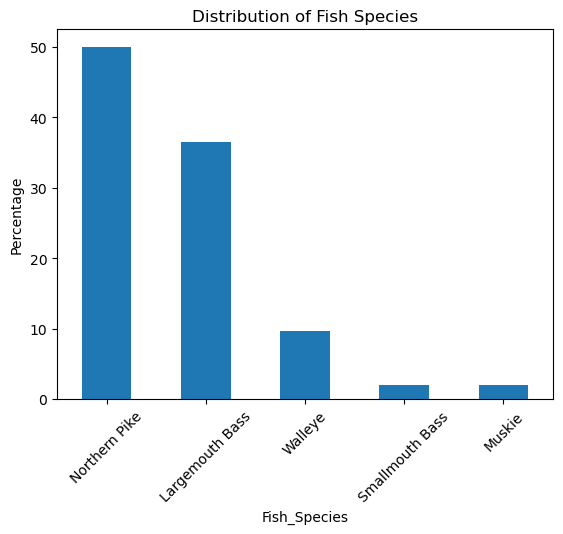

In [ ]:
class_percent.plot(kind="bar")
plt.title("Distribution of Fish Species")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()

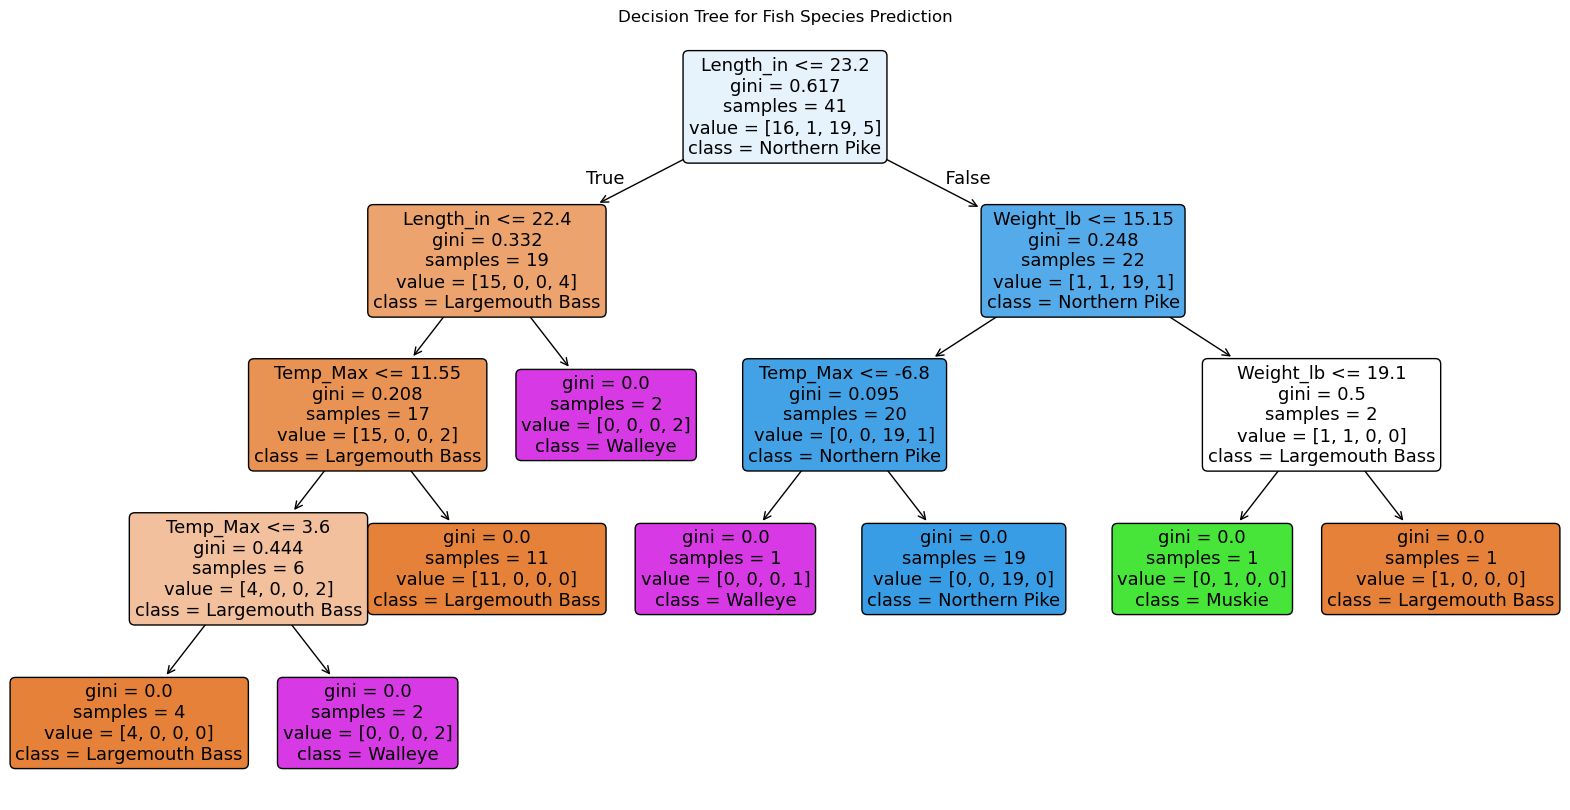

In [ ]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

class_names = encoders["Fish_Species"].inverse_transform(tree_model.classes_)

plt.figure(figsize=(20,10))

plot_tree(
    tree_model,
    feature_names=X_train.columns,
    class_names=class_names,
    filled=True,
    rounded=True
)

plt.title("Decision Tree for Fish Species Prediction")
plt.show()

We wanted to look at the confusion tree for our kNN model because it was the more accurate of the two models. As shown in the chart, we see that  our model is only predicting Largemouth Bass and Northern Pike. One solution to this would be to gather more data points. The only constraint is the time needed to collect data. 

In [489]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

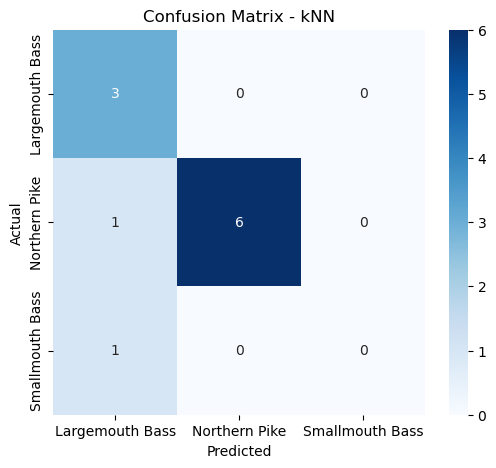

In [490]:
plt.figure(figsize=(6,5))
labels = encoders["Fish_Species"].inverse_transform(sorted(set(y_test)))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=labels,
            yticklabels=labels,
            cmap="Blues")
plt.title("Confusion Matrix - kNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Conclusion

Overall the data suggest that Temperature and the Type of bait you use has the biggest impact on the fish you will catch. What I was not expecting was Ice Fishing and Summer fishing to have no significant difference. 

Our classifiers performed suprisngly well. We used KNN and Decision Tree and KNN was more accurate. It showed the ability to be able to predict the type of species that would be caught given the metrics. One challenge was the limited Data size. Unfortunately I am not able to fish everyday so this made it difficult to get enough data to suffice. 

This would nonetheless benefit any angler in Wisconsin. It clearly shows what is important when it comes to fishing and what is not. It could also be used by commercial industries to know what to focus when selling fishing gear. 

Sources:  
ChatGPT  
itsfoss.com  
https://open-meteo.com/